## setup

In [ ]:
# import os
# from google.colab import drive

# # 1. Unmount Google Drive if it's mounted
# # This helps prevent issues with residual files when trying to remount
# if os.path.exists('/content/drive'):
#   try:
#     drive.flush_and_unmount()
#     print('Google Drive unmounted successfully.')
#   except ValueError:
#     print('Google Drive was not mounted or could not be unmounted.')
#   except Exception as e:
#     print(f'Error unmounting Google Drive: {e}')

# # 2. Remove the /content/drive directory if it still exists (after unmount)
# # This is a precaution if unmount didn't completely clear the mount point
# if os.path.exists('/content/drive'):
#   print('Removing /content/drive directory...')
#   !rm -rf /content/drive
#   print('Removed /content/drive.')

# # 3. Remove the unzipped data directory
# # This clears any extracted files from previous runs
# unzip_dir = '/content/Netflix_unzipped'
# if os.path.exists(unzip_dir):
#   print(f'Removing {unzip_dir} directory...')
#   !rm -rf {unzip_dir}
#   print(f'Removed {unzip_dir}.')

# print('Cleanup complete.')

Drive not mounted, so nothing to flush and unmount.
Google Drive unmounted successfully.
Removing /content/drive directory...
Removed /content/drive.
Removing /content/Netflix_unzipped directory...
Removed /content/Netflix_unzipped.
Cleanup complete.


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## input files and file conversions

In [8]:
import os
import pandas as pd
from tqdm import tqdm # For progress bar
from google.colab import drive # Import drive for mounting if not already
import gc # Import garbage collector for memory management

# Define paths
zip_file_path = '/content/drive/MyDrive/Netflix/archive.zip'
unzip_dir = '/content/Netflix_unzipped'
save_dir = '/content/drive/MyDrive/Netflix_processed_individual_files/netflix' # New directory for individual processed files

# # 1. Ensure Google Drive is mounted for output (if not already)
# if not os.path.exists('/content/drive'):
#     print("Google Drive not mounted. Attempting to mount...")
#     drive.mount('/content/drive')
#     print("Google Drive mounted.")

# # 2. Create the directory to unzip into if it doesn't exist
# os.makedirs(unzip_dir, exist_ok=True)

# # 3. Unzip the file
# print(f"Unzipping {zip_file_path} to {unzip_dir}...")
# # Use -o to overwrite existing files, -q for quiet
# !unzip -o -q {zip_file_path} -d {unzip_dir}
# print(f"Unzipping complete. Contents of {unzip_dir}:")
# !ls -F {unzip_dir}

# # 4. Create a directory to save individual processed CSVs
# os.makedirs(save_dir, exist_ok=True)
# print(f"\nCreated directory for processed files: {save_dir}")

# Function to process combined_data_X.txt files (adapted from existing notebook logic)
def process_combined_data_file(file_path):
    reviews_data = []
    current_movie_id = None
    print(f"\nProcessing {file_path}...")
    with open(file_path, 'r', encoding='ISO-8859-1') as f:
        for line in tqdm(f, desc=f"Processing {os.path.basename(file_path)}"):
            line = line.strip()
            if line.endswith(':'):
                current_movie_id = int(line[:-1])
            elif current_movie_id is not None:
                try:
                    customer_id, rating, date = line.split(',')
                    reviews_data.append({
                        'Movie_ID': current_movie_id,
                        'Customer_ID': int(customer_id),
                        'Rating': int(rating),
                        'Date': date
                    })
                except ValueError:
                    # Skip malformed lines
                    pass
    df = pd.DataFrame(reviews_data)
    df['Date'] = pd.to_datetime(df['Date'])
    return df

# 5. Process and store each combined_data_X.txt file separately
combined_data_files = [
    os.path.join(unzip_dir, 'combined_data_1.txt'),
    os.path.join(unzip_dir, 'combined_data_2.txt'),
    os.path.join(unzip_dir, 'combined_data_3.txt'),
    os.path.join(unzip_dir, 'combined_data_4.txt')
]

print("\n--- Starting individual file processing and saving ---")

# Process combined_data_1.txt
file_path_1 = combined_data_files[0]
try:
    print(f"\n--- Processing {os.path.basename(file_path_1)} ---")
    df_individual_1 = process_combined_data_file(file_path_1)
    file_name_1 = os.path.basename(file_path_1).replace('.txt', '.csv')
    output_path_1 = os.path.join(save_dir, file_name_1)
    df_individual_1.to_csv(output_path_1, index=False)
    print(f"Successfully processed and saved {file_name_1} to {output_path_1}")
    print(f"Head of {file_name_1}:\n{df_individual_1.head()}")
    print(f"Info of {file_name_1}:\n")
    df_individual_1.info()
    del df_individual_1 # Clear DataFrame from memory
    gc.collect() # Manually trigger garbage collection
    print(f"Memory cleared for {file_name_1}")
except Exception as e:
    print(f"Error processing {file_path_1}: {e}")

# Process combined_data_2.txt
file_path_2 = combined_data_files[1]
try:
    print(f"\n--- Processing {os.path.basename(file_path_2)} ---")
    df_individual_2 = process_combined_data_file(file_path_2)
    file_name_2 = os.path.basename(file_path_2).replace('.txt', '.csv')
    output_path_2 = os.path.join(save_dir, file_name_2)
    df_individual_2.to_csv(output_path_2, index=False)
    print(f"Successfully processed and saved {file_name_2} to {output_path_2}")
    print(f"Head of {file_name_2}:\n{df_individual_2.head()}")
    print(f"Info of {file_name_2}:\n")
    df_individual_2.info()
    del df_individual_2 # Clear DataFrame from memory
    gc.collect() # Manually trigger garbage collection
    print(f"Memory cleared for {file_name_2}")
except Exception as e:
    print(f"Error processing {file_path_2}: {e}")

# # Process combined_data_3.txt
# file_path_3 = combined_data_files[2]
# try:
#     print(f"\n--- Processing {os.path.basename(file_path_3)} ---")
#     df_individual_3 = process_combined_data_file(file_path_3)
#     file_name_3 = os.path.basename(file_path_3).replace('.txt', '.csv')
#     output_path_3 = os.path.join(save_dir, file_name_3)
#     df_individual_3.to_csv(output_path_3, index=False)
#     print(f"Successfully processed and saved {file_name_3} to {output_path_3}")
#     print(f"Head of {file_name_3}:\n{df_individual_3.head()}")
#     print(f"Info of {file_name_3}:\n")
#     df_individual_3.info()
#     del df_individual_3 # Clear DataFrame from memory
#     gc.collect() # Manually trigger garbage collection
#     print(f"Memory cleared for {file_name_3}")
# except Exception as e:
#     print(f"Error processing {file_path_3}: {e}")

# # Process combined_data_4.txt
# file_path_4 = combined_data_files[3]
# try:
#     print(f"\n--- Processing {os.path.basename(file_path_4)} ---")
#     df_individual_4 = process_combined_data_file(file_path_4)
#     file_name_4 = os.path.basename(file_path_4).replace('.txt', '.csv')
#     output_path_4 = os.path.join(save_dir, file_name_4)
#     df_individual_4.to_csv(output_path_4, index=False)
#     print(f"Successfully processed and saved {file_name_4} to {output_path_4}")
#     print(f"Head of {file_name_4}:\n{df_individual_4.head()}")
#     print(f"Info of {file_name_4}:\n")
#     df_individual_4.info()
#     del df_individual_4 # Clear DataFrame from memory
#     gc.collect() # Manually trigger garbage collection
#     print(f"Memory cleared for {file_name_4}")
# except Exception as e:
#     print(f"Error processing {file_path_4}: {e}")

print("\nAll combined_data files processed and saved separately.")



--- Starting individual file processing and saving ---

--- Processing combined_data_1.txt ---

Processing /content/Netflix_unzipped/combined_data_1.txt...


Processing combined_data_1.txt: 24058263it [00:47, 507767.35it/s]


Successfully processed and saved combined_data_1.csv to /content/drive/MyDrive/Netflix_processed_individual_files/netflix/combined_data_1.csv
Head of combined_data_1.csv:
   Movie_ID  Customer_ID  Rating       Date
0         1      1488844       3 2005-09-06
1         1       822109       5 2005-05-13
2         1       885013       4 2005-10-19
3         1        30878       4 2005-12-26
4         1       823519       3 2004-05-03
Info of combined_data_1.csv:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24053764 entries, 0 to 24053763
Data columns (total 4 columns):
 #   Column       Dtype         
---  ------       -----         
 0   Movie_ID     int64         
 1   Customer_ID  int64         
 2   Rating       int64         
 3   Date         datetime64[ns]
dtypes: datetime64[ns](1), int64(3)
memory usage: 734.1 MB
Memory cleared for combined_data_1.csv

--- Processing combined_data_2.txt ---

Processing /content/Netflix_unzipped/combined_data_2.txt...


Processing combined_data_2.txt: 12462754it [00:21, 566593.26it/s]


Error processing /content/Netflix_unzipped/combined_data_2.txt: time data "2" doesn't match format "%Y-%m-%d", at position 2180. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

All combined_data files processed and saved separately.


In [9]:
import os
import pandas as pd
from tqdm import tqdm # For progress bar
import gc # Import garbage collector for memory management

# Define paths (copying from previous cell to make this self-contained for testing)
unzip_dir = '/content/Netflix_unzipped'
save_dir = '/content/drive/MyDrive/Netflix_processed_individual_files/netflix'

# Function to process combined_data_X.txt files (adapted with error handling for dates)
def process_combined_data_file(file_path):
    reviews_data = []
    current_movie_id = None
    print(f"\nProcessing {file_path}...")
    with open(file_path, 'r', encoding='ISO-8859-1') as f:
        for line in tqdm(f, desc=f"Processing {os.path.basename(file_path)}"):
            line = line.strip()
            if line.endswith(':'):
                current_movie_id = int(line[:-1])
            elif current_movie_id is not None:
                try:
                    customer_id, rating, date = line.split(',')
                    reviews_data.append({
                        'Movie_ID': current_movie_id,
                        'Customer_ID': int(customer_id),
                        'Rating': int(rating),
                        'Date': date
                    })
                except ValueError:
                    # Skip malformed lines that can't be split correctly
                    pass
    df = pd.DataFrame(reviews_data)
    # Modified: Use errors='coerce' to handle malformed date strings, converting them to NaT
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    return df

# Ensure the save directory exists (if not created by a previous cell)
os.makedirs(save_dir, exist_ok=True)

print("\n--- Starting individual file processing and saving for combined_data_2.txt ---")

# Process combined_data_2.txt only
file_path_2 = os.path.join(unzip_dir, 'combined_data_2.txt')
try:
    print(f"\n--- Processing {os.path.basename(file_path_2)} ---")
    df_individual_2 = process_combined_data_file(file_path_2)
    file_name_2 = os.path.basename(file_path_2).replace('.txt', '.csv')
    output_path_2 = os.path.join(save_dir, file_name_2)
    df_individual_2.to_csv(output_path_2, index=False)
    print(f"Successfully processed and saved {file_name_2} to {output_path_2}")
    print(f"Head of {file_name_2}:\n{df_individual_2.head()}")
    print(f"Info of {file_name_2}:\n")
    df_individual_2.info()
    del df_individual_2 # Clear DataFrame from memory
    gc.collect() # Manually trigger garbage collection
    print(f"Memory cleared for {file_name_2}")
except Exception as e:
    print(f"Error processing {file_path_2}: {e}")

print("\nFinished processing combined_data_2.txt.")



--- Starting individual file processing and saving for combined_data_2.txt ---

--- Processing combined_data_2.txt ---

Processing /content/Netflix_unzipped/combined_data_2.txt...


Processing combined_data_2.txt: 12462754it [00:19, 649221.12it/s]


Successfully processed and saved combined_data_2.csv to /content/drive/MyDrive/Netflix_processed_individual_files/netflix/combined_data_2.csv
Head of combined_data_2.csv:
   Movie_ID  Customer_ID  Rating       Date
0      4500      2532865       4 2005-07-26
1      4500       573364       3 2005-06-20
2      4500      1696725       3 2004-02-27
3      4500      1253431       3 2004-03-31
4      4500      1265574       2 2003-09-01
Info of combined_data_2.csv:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12460778 entries, 0 to 12460777
Data columns (total 4 columns):
 #   Column       Dtype         
---  ------       -----         
 0   Movie_ID     int64         
 1   Customer_ID  int64         
 2   Rating       int64         
 3   Date         datetime64[ns]
dtypes: datetime64[ns](1), int64(3)
memory usage: 380.3 MB
Memory cleared for combined_data_2.csv

Finished processing combined_data_2.txt.


In [11]:
import os
import pandas as pd
import shutil
from tqdm import tqdm
import gc

# Define paths (ensure these match the setup in previous cells)
unzip_dir = '/content/Netflix_unzipped'
save_dir = '/content/drive/MyDrive/Netflix_processed_individual_files/netflix'

# Ensure the save directory exists
os.makedirs(save_dir, exist_ok=True)

print(f"Current save directory: {save_dir}")

# --- 1. Copy movie_titles.csv ---
movie_titles_source_path = os.path.join(unzip_dir, 'movie_titles.csv')
movie_titles_dest_path = os.path.join(save_dir, 'movie_titles.csv')

try:
    shutil.copy(movie_titles_source_path, movie_titles_dest_path)
    print(f"\nSuccessfully copied {os.path.basename(movie_titles_source_path)} to {movie_titles_dest_path}")
except FileNotFoundError:
    print(f"Error: {movie_titles_source_path} not found. Please ensure it was unzipped correctly.")
except Exception as e:
    print(f"Error copying movie_titles.csv: {e}")

# --- 2. Analyze probe.txt and qualifying.txt structure and process them ---
print("\n--- Inspecting probe.txt ---")
!head -n 10 {os.path.join(unzip_dir, 'probe.txt')}

print("\n--- Inspecting qualifying.txt ---")
!head -n 10 {os.path.join(unzip_dir, 'qualifying.txt')}

# Function to process probe.txt (Movie ID followed by customer IDs)
def process_probe_file(file_path):
    data = []
    current_movie_id = None
    print(f"\nProcessing {file_path}...")
    with open(file_path, 'r', encoding='ISO-8859-1') as f:
        for line in tqdm(f, desc=f"Processing {os.path.basename(file_path)}"):
            line = line.strip()
            if line.endswith(':'):
                current_movie_id = int(line[:-1])
            else:
                try:
                    customer_id = int(line)
                    data.append({
                        'Movie_ID': current_movie_id,
                        'Customer_ID': customer_id
                    })
                except ValueError:
                    # Skip malformed lines
                    pass
    df = pd.DataFrame(data)
    return df

# Function to process qualifying.txt (Movie ID, then customer_id,date)
def process_qualifying_file(file_path):
    data = []
    current_movie_id = None
    print(f"\nProcessing {file_path}...")
    with open(file_path, 'r', encoding='ISO-8859-1') as f:
        for line in tqdm(f, desc=f"Processing {os.path.basename(file_path)}"):
            line = line.strip()
            if line.endswith(':'):
                current_movie_id = int(line[:-1])
            else:
                try:
                    customer_id, date = line.split(',')
                    data.append({
                        'Movie_ID': current_movie_id,
                        'Customer_ID': int(customer_id),
                        'Date': date
                    })
                except ValueError:
                    # Skip malformed lines
                    pass
    df = pd.DataFrame(data)
    # Convert 'Date' column to datetime, coercing errors to NaT
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    return df


# --- Process probe.txt ---
probe_file_path = os.path.join(unzip_dir, 'probe.txt')
probe_output_name = 'probe.csv'
probe_output_path = os.path.join(save_dir, probe_output_name)

try:
    print(f"\n--- Processing {os.path.basename(probe_file_path)} ---")
    df_probe = process_probe_file(probe_file_path)
    df_probe.to_csv(probe_output_path, index=False)
    print(f"Successfully processed and saved {probe_output_name} to {probe_output_path}")
    print(f"Head of {probe_output_name}:\n{df_probe.head()}")
    print(f"Info of {probe_output_name}:\n")
    df_probe.info()
    del df_probe
    gc.collect()
    print(f"Memory cleared for {probe_output_name}")
except Exception as e:
    print(f"Error processing probe.txt: {e}")

# --- Process qualifying.txt ---
qualifying_file_path = os.path.join(unzip_dir, 'qualifying.txt')
qualifying_output_name = 'qualifying.csv'
qualifying_output_path = os.path.join(save_dir, qualifying_output_name)

try:
    print(f"\n--- Processing {os.path.basename(qualifying_file_path)} ---")
    # Use the new function specifically for qualifying.txt
    df_qualifying = process_qualifying_file(qualifying_file_path)
    df_qualifying.to_csv(qualifying_output_path, index=False)
    print(f"Successfully processed and saved {qualifying_output_name} to {qualifying_output_path}")
    print(f"Head of {qualifying_output_name}:\n{df_qualifying.head()}")
    print(f"Info of {qualifying_output_name}:\n")
    df_qualifying.info()
    del df_qualifying
    gc.collect()
    print(f"Memory cleared for {qualifying_output_name}")
except Exception as e:
    print(f"Error processing qualifying.txt: {e}")

print("\nAll requested files processed and saved.")


Current save directory: /content/drive/MyDrive/Netflix_processed_individual_files/netflix

Successfully copied movie_titles.csv to /content/drive/MyDrive/Netflix_processed_individual_files/netflix/movie_titles.csv

--- Inspecting probe.txt ---
1:
30878
2647871
1283744
2488120
317050
1904905
1989766
14756
1027056

--- Inspecting qualifying.txt ---
1:
1046323,2005-12-19
1080030,2005-12-23
1830096,2005-03-14
368059,2005-05-26
802003,2005-11-07
513509,2005-07-04
1086137,2005-09-21
428698,2005-12-20
515850,2005-11-27

--- Processing probe.txt ---

Processing /content/Netflix_unzipped/probe.txt...


Processing probe.txt: 1425333it [00:02, 711284.40it/s]


Successfully processed and saved probe.csv to /content/drive/MyDrive/Netflix_processed_individual_files/netflix/probe.csv
Head of probe.csv:
   Movie_ID  Customer_ID
0         1        30878
1         1      2647871
2         1      1283744
3         1      2488120
4         1       317050
Info of probe.csv:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1408395 entries, 0 to 1408394
Data columns (total 2 columns):
 #   Column       Non-Null Count    Dtype
---  ------       --------------    -----
 0   Movie_ID     1408395 non-null  int64
 1   Customer_ID  1408395 non-null  int64
dtypes: int64(2)
memory usage: 21.5 MB
Memory cleared for probe.csv

--- Processing qualifying.txt ---

Processing /content/Netflix_unzipped/qualifying.txt...


Processing qualifying.txt: 2834601it [00:03, 822642.73it/s]


Successfully processed and saved qualifying.csv to /content/drive/MyDrive/Netflix_processed_individual_files/netflix/qualifying.csv
Head of qualifying.csv:
   Movie_ID  Customer_ID       Date
0         1      1046323 2005-12-19
1         1      1080030 2005-12-23
2         1      1830096 2005-03-14
3         1       368059 2005-05-26
4         1       802003 2005-11-07
Info of qualifying.csv:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2817131 entries, 0 to 2817130
Data columns (total 3 columns):
 #   Column       Dtype         
---  ------       -----         
 0   Movie_ID     int64         
 1   Customer_ID  int64         
 2   Date         datetime64[ns]
dtypes: datetime64[ns](1), int64(2)
memory usage: 64.5 MB
Memory cleared for qualifying.csv

All requested files processed and saved.


## loading dataset

In [14]:
import os
import pandas as pd

# Define the directory where the CSV files are saved
save_dir = '/content/drive/MyDrive/Netflix_processed_individual_files/netflix'

# List all CSV files in the directory
csv_files = [f for f in os.listdir(save_dir) if f.endswith('.csv')]

if not csv_files:
    print(f"No CSV files found in {save_dir}")
else:
    print(f"Found {len(csv_files)} CSV files in {save_dir}. Loading and showing head for each:\n")

    for csv_file in sorted(csv_files): # Sort for consistent output order
        file_path = os.path.join(save_dir, csv_file)
        try:
            print(f"--- Loading {csv_file} ---")
            if csv_file == 'movie_titles.csv':
                # Custom parsing for movie_titles.csv due to commas in titles
                movie_data = []
                with open(file_path, 'r', encoding='ISO-8859-1') as f:
                    for line in f:
                        parts = line.strip().split(',')
                        # Expects ID, Year, Title. Title can have commas.
                        # The first part is Movie_ID, second is Year, rest is Title.
                        movie_id = int(parts[0])
                        year = int(parts[1]) if parts[1].isdigit() else None # Handle potential non-numeric year
                        title = ','.join(parts[2:]) # Rejoin the rest as title
                        movie_data.append({'Movie_ID': movie_id, 'Year': year, 'Title': title})
                df = pd.DataFrame(movie_data)
            else:
                df = pd.read_csv(file_path)
            print(f"Head of {csv_file}:\n{df.head()}\n")
        except Exception as e:
            print(f"Error loading {csv_file}: {e}\n")

print("Finished loading and displaying heads of all CSV files.")


Found 7 CSV files in /content/drive/MyDrive/Netflix_processed_individual_files/netflix. Loading and showing head for each:

--- Loading combined_data_1.csv ---
Head of combined_data_1.csv:
   Movie_ID  Customer_ID  Rating        Date
0         1      1488844       3  2005-09-06
1         1       822109       5  2005-05-13
2         1       885013       4  2005-10-19
3         1        30878       4  2005-12-26
4         1       823519       3  2004-05-03

--- Loading combined_data_2.csv ---
Head of combined_data_2.csv:
   Movie_ID  Customer_ID  Rating        Date
0      4500      2532865       4  2005-07-26
1      4500       573364       3  2005-06-20
2      4500      1696725       3  2004-02-27
3      4500      1253431       3  2004-03-31
4      4500      1265574       2  2003-09-01

--- Loading combined_data_3.csv ---
Head of combined_data_3.csv:
   Movie_ID  Customer_ID  Rating        Date
0      9211      1277134       1  2003-12-02
1      9211      2435457       2  2005-06-01
2   

In [15]:
import os
import pandas as pd
import gc

# Define the directory where the CSV files are saved
save_dir = '/content/drive/MyDrive/Netflix_processed_individual_files/netflix'

# List of individual combined_data CSV files
combined_data_csvs = [
    os.path.join(save_dir, 'combined_data_1.csv'),
    os.path.join(save_dir, 'combined_data_2.csv'),
    os.path.join(save_dir, 'combined_data_3.csv'),
    os.path.join(save_dir, 'combined_data_4.csv')
]

all_dfs = []
print("\n--- Combining individual combined_data CSVs ---")

for csv_file_path in combined_data_csvs:
    try:
        print(f"Loading {os.path.basename(csv_file_path)}...")
        df_part = pd.read_csv(csv_file_path, dtype={'Movie_ID': int, 'Customer_ID': int, 'Rating': int}, parse_dates=['Date'])
        all_dfs.append(df_part)
        print(f"Loaded {os.path.basename(csv_file_path)} with {len(df_part)} rows.")
        del df_part # Clear individual DataFrame part after appending
        gc.collect()
    except FileNotFoundError:
        print(f"Warning: {csv_file_path} not found. Skipping.")
    except Exception as e:
        print(f"Error loading {csv_file_path}: {e}")

if all_dfs:
    print("Concatenating all DataFrames...")
    combined_data_df = pd.concat(all_dfs, ignore_index=True)
    print(f"Combined DataFrame created with {len(combined_data_df)} rows.")

    # Save the combined DataFrame
    output_combined_path = os.path.join(save_dir, 'combined_data.csv')
    print(f"Saving combined_data.csv to {output_combined_path}...")
    combined_data_df.to_csv(output_combined_path, index=False)
    print("Successfully saved combined_data.csv")

    print("\nHead of combined_data.csv:")
    print(combined_data_df.head())
    print("\nInfo of combined_data.csv:")
    combined_data_df.info()

    del combined_data_df # Clear the combined DataFrame from memory
    gc.collect()
    print("Memory cleared for combined_data_df.")
else:
    print("No combined_data CSVs were loaded. Cannot create combined_data.csv.")

print("\nFinished combining and saving combined_data.csv.")



--- Combining individual combined_data CSVs ---
Loading combined_data_1.csv...
Loaded combined_data_1.csv with 24053764 rows.
Loading combined_data_2.csv...
Loaded combined_data_2.csv with 12460778 rows.
Loading combined_data_3.csv...
Loaded combined_data_3.csv with 22601629 rows.
Loading combined_data_4.csv...
Loaded combined_data_4.csv with 26847523 rows.
Concatenating all DataFrames...
Combined DataFrame created with 85963694 rows.
Saving combined_data.csv to /content/drive/MyDrive/Netflix_processed_individual_files/netflix/combined_data.csv...
Successfully saved combined_data.csv

Head of combined_data.csv:
   Movie_ID  Customer_ID  Rating       Date
0         1      1488844       3 2005-09-06
1         1       822109       5 2005-05-13
2         1       885013       4 2005-10-19
3         1        30878       4 2005-12-26
4         1       823519       3 2004-05-03

Info of combined_data.csv:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85963694 entries, 0 to 85963693
Data c

## EDA

In [16]:
# Install PySpark
!pip install pyspark

import os
from pyspark.sql import SparkSession
from pyspark.sql.functions import col

# Define the directory where the combined CSV file is saved
save_dir = '/content/drive/MyDrive/Netflix_processed_individual_files/netflix'
combined_data_path = os.path.join(save_dir, 'combined_data.csv')

# 1. Initialize SparkSession
print("\nInitializing SparkSession...")
spark = SparkSession.builder\
    .appName("NetflixDataAnalysis")\
    .getOrCreate()
print("SparkSession initialized.")

# 2. Load the combined_data.csv into a Spark DataFrame
print(f"\nLoading combined_data.csv from {combined_data_path} into Spark DataFrame...")
try:
    spark_df = spark.read.csv(combined_data_path, header=True, inferSchema=True)
    print("Combined data loaded successfully into Spark DataFrame.")

    # 3. Show schema and basic statistics
    print("\n--- Spark DataFrame Schema ---")
    spark_df.printSchema()

    print("\n--- First 5 rows of Spark DataFrame ---")
    spark_df.show(5)

    print("\n--- Overall Statistics (describe) ---")
    spark_df.describe().show()

    print("\n--- Number of records ---")
    print(f"Total records: {spark_df.count()}")

    print("\n--- Number of unique Movies ---")
    spark_df.select(col("Movie_ID")).distinct().count()
    unique_movies = spark_df.select("Movie_ID").distinct().count()
    print(f"Number of unique movies: {unique_movies}")

    print("\n--- Number of unique Customers ---")
    unique_customers = spark_df.select("Customer_ID").distinct().count()
    print(f"Number of unique customers: {unique_customers}")

    print("\n--- Rating Distribution ---")
    spark_df.groupBy("Rating").count().orderBy("Rating").show()

    # Find the range of dates
    min_date = spark_df.agg({"Date": "min"}).collect()[0][0]
    max_date = spark_df.agg({"Date": "max"}).collect()[0][0]
    print(f"\n--- Date Range ---")
    print(f"Earliest Date: {min_date}")
    print(f"Latest Date: {max_date}")

except Exception as e:
    print(f"Error loading or processing combined_data.csv with Spark: {e}")

# It's good practice to stop the SparkSession when you're done
# spark.stop()
# print("SparkSession stopped.")



Initializing SparkSession...
SparkSession initialized.

Loading combined_data.csv from /content/drive/MyDrive/Netflix_processed_individual_files/netflix/combined_data.csv into Spark DataFrame...
Combined data loaded successfully into Spark DataFrame.

--- Spark DataFrame Schema ---
root
 |-- Movie_ID: integer (nullable = true)
 |-- Customer_ID: integer (nullable = true)
 |-- Rating: integer (nullable = true)
 |-- Date: date (nullable = true)


--- First 5 rows of Spark DataFrame ---
+--------+-----------+------+----------+
|Movie_ID|Customer_ID|Rating|      Date|
+--------+-----------+------+----------+
|       1|    1488844|     3|2005-09-06|
|       1|     822109|     5|2005-05-13|
|       1|     885013|     4|2005-10-19|
|       1|      30878|     4|2005-12-26|
|       1|     823519|     3|2004-05-03|
+--------+-----------+------+----------+
only showing top 5 rows

--- Overall Statistics (describe) ---
+-------+-----------------+------------------+------------------+
|summary|    

Starting detailed analysis with PySpark...
Loading movie_titles.csv from /content/drive/MyDrive/Netflix_processed_individual_files/netflix/movie_titles.csv...
movie_titles.csv loaded and parsed successfully.

--- A. User Activity Patterns ---
Generating visualizations for User Activity...


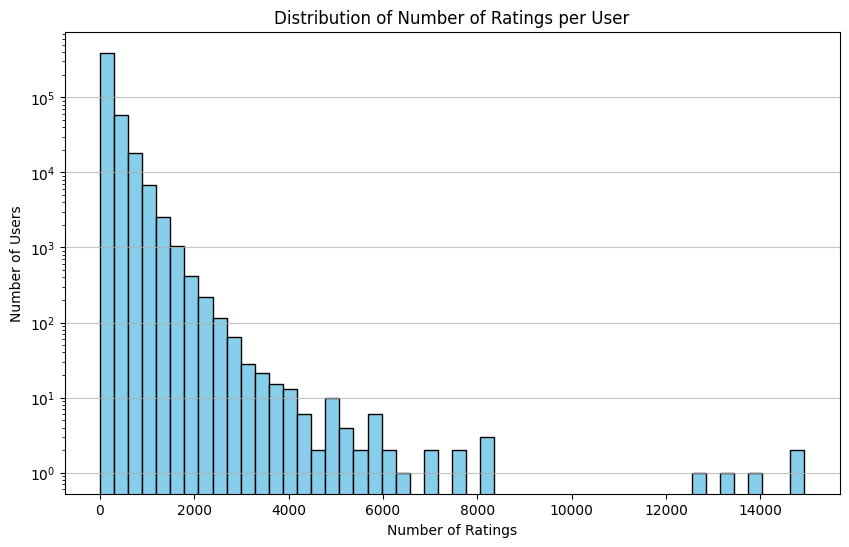

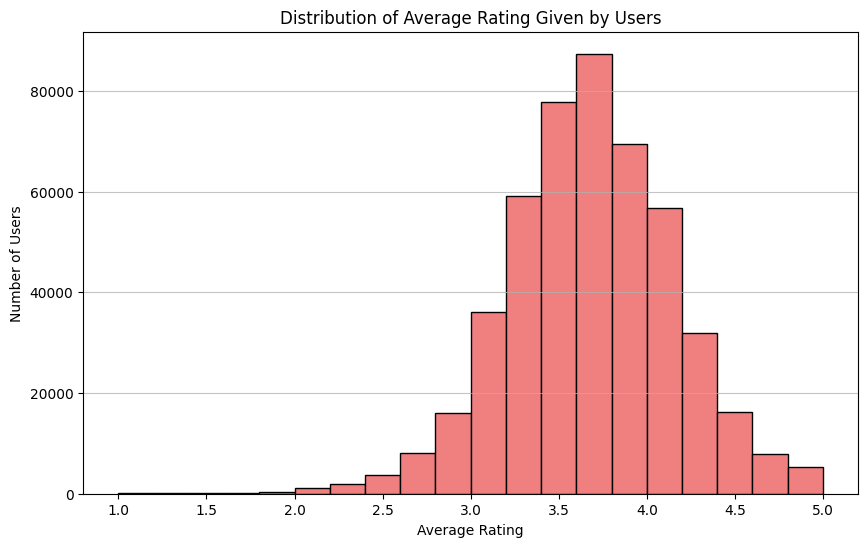

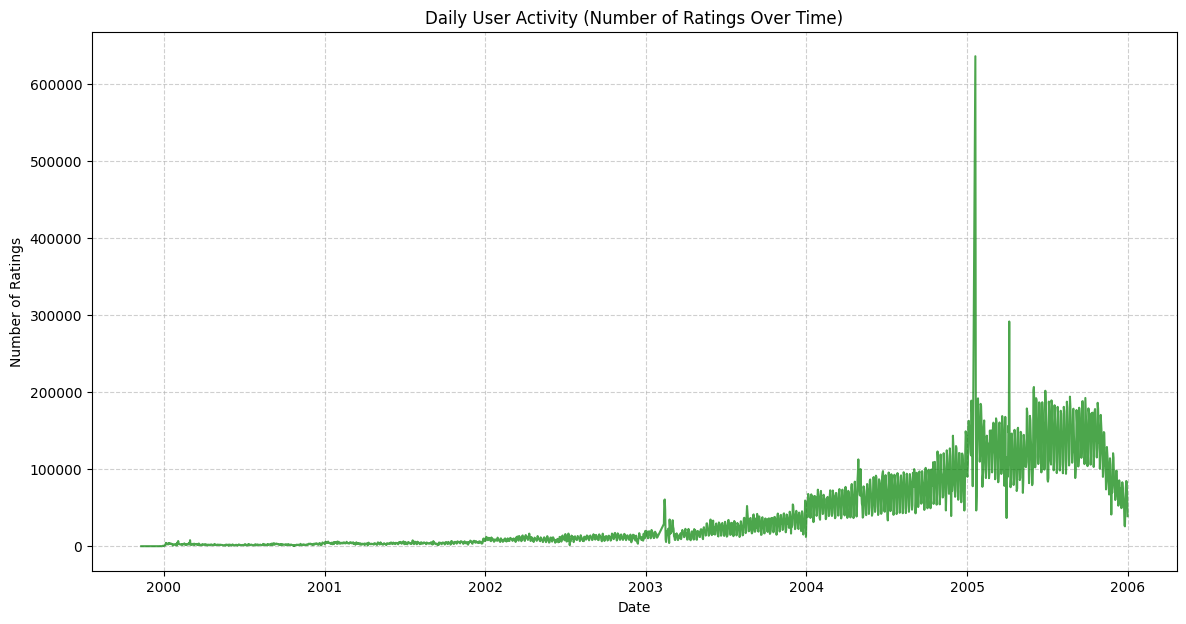


--- B. Content Popularity Trends ---

Top 10 Movies by Number of Ratings:
+--------+-----------+------------------+----+------------------------------------------------------+
|Movie_ID|num_ratings|avg_rating        |Year|Title                                                 |
+--------+-----------+------------------+----+------------------------------------------------------+
|5317    |232944     |3.361267085651487 |2000|Miss Congeniality                                     |
|15124   |216596     |3.724237751389684 |1996|Independence Day                                      |
|14313   |200832     |3.7838541666666665|2000|The Patriot                                           |
|15205   |196397     |3.4421656135277017|2004|The Day After Tomorrow                                |
|1905    |193941     |4.153907631702425 |2003|Pirates of the Caribbean: The Curse of the Black Pearl|
|6287    |193295     |3.905046690292041 |1990|Pretty Woman                                          |
|11283 

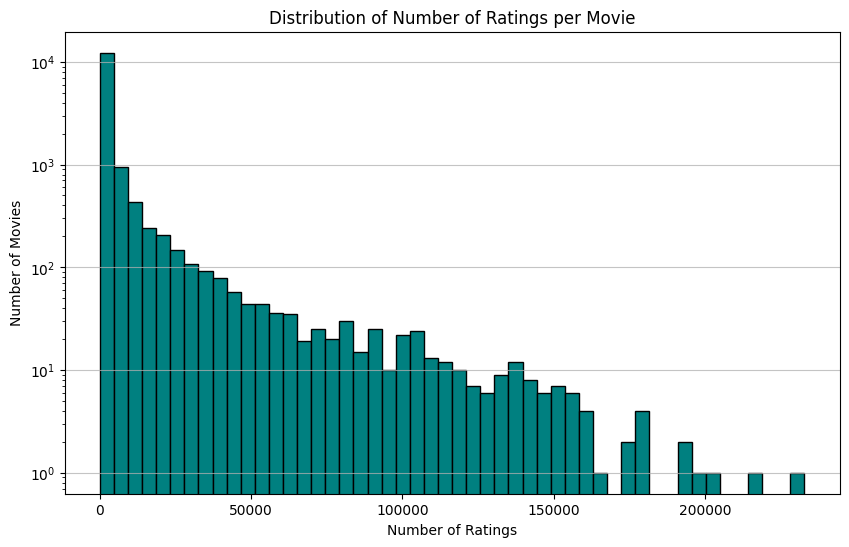

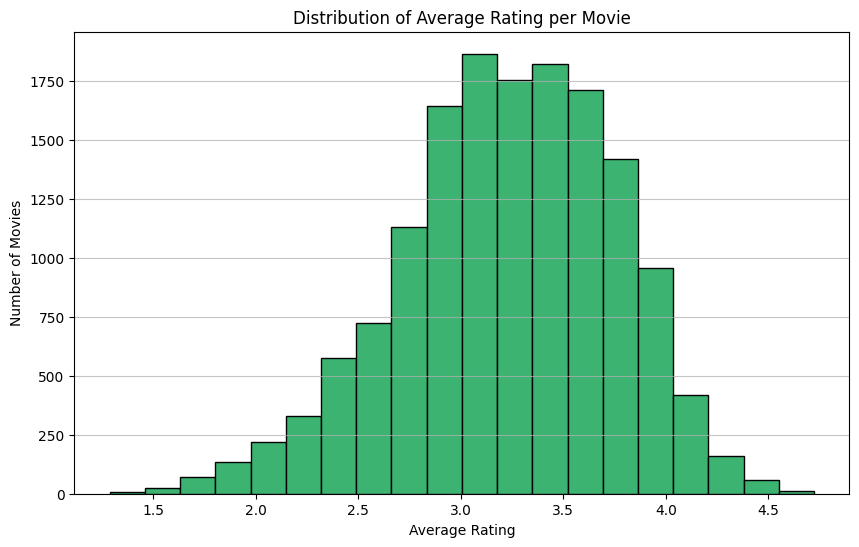


--- C. Rating Distributions ---
+------+--------+
|Rating|   count|
+------+--------+
|     1| 3936222|
|     2| 8645570|
|     3|24599762|
|     4|28878402|
|     5|19903738|
+------+--------+

Generating visualization for Rating Distribution...


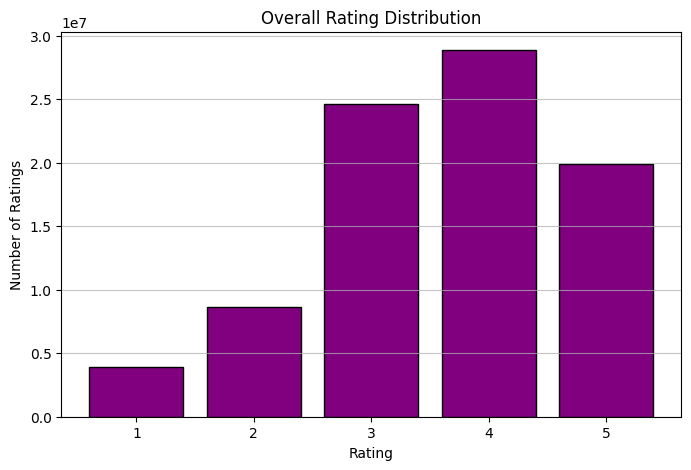


--- D. Data Sparsity Characteristics ---
Total number of actual ratings: 85963694
Total number of unique users: 480008
Total number of unique movies: 15035
Total possible ratings (Unique Users * Unique Movies): 7216920280
Data Sparsity: 0.9881 (meaning 98.81% of possible ratings are missing)


In [17]:
# Install PySpark and Matplotlib if not already installed
# !pip install pyspark matplotlib

import os
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, avg
from pyspark.sql.types import StructType, StructField, IntegerType, StringType

# Define paths (as established in previous cells)
save_dir = '/content/drive/MyDrive/Netflix_processed_individual_files/netflix'
combined_data_path = os.path.join(save_dir, 'combined_data.csv')
movie_titles_path = os.path.join(save_dir, 'movie_titles.csv')

# Ensure SparkSession is available (it was initialized in a previous cell)
# If running this cell independently, uncomment the following lines:
# spark = SparkSession.builder.appName("NetflixDetailedAnalysis").getOrCreate()
# spark_df = spark.read.csv(combined_data_path, header=True, inferSchema=True)

print("Starting detailed analysis with PySpark...")

# 1. Load Movie Titles Data (needed for Content Popularity Trends)
# Custom schema for movie_titles.csv to handle parsing issues
movie_titles_schema = StructType([
    StructField("Movie_ID", IntegerType(), True),
    StructField("Year", IntegerType(), True),
    StructField("Title", StringType(), True)
])

# Function to parse lines of movie_titles.csv due to embedded commas
def parse_movie_line(line):
    parts = line.strip().split(',')
    movie_id = int(parts[0])
    # Handle potential non-numeric year gracefully
    year_val = int(parts[1]) if parts[1].isdigit() else None
    title = ','.join(parts[2:])
    return movie_id, year_val, title

print(f"Loading movie_titles.csv from {movie_titles_path}...")
# Read as text, parse using RDD, then convert to DataFrame
movie_titles_rdd = spark.sparkContext.textFile(movie_titles_path).map(parse_movie_line)
movie_titles_df = spark.createDataFrame(movie_titles_rdd, schema=movie_titles_schema)
print("movie_titles.csv loaded and parsed successfully.")
# movie_titles_df.show(5, truncate=False)

# --- A. User activity patterns ---
print("\n--- A. User Activity Patterns ---")

# Ratings per user
ratings_per_user = spark_df.groupBy("Customer_ID").agg(count("Rating").alias("num_ratings"))

# Average rating given by users
avg_rating_per_user = spark_df.groupBy("Customer_ID").agg(avg("Rating").alias("avg_rating"))

# User activity over time (ratings per day)
ratings_by_date = spark_df.groupBy("Date").agg(count("Rating").alias("daily_ratings")).orderBy("Date")

print("Generating visualizations for User Activity...")
# Collect minimal aggregated data for Matplotlib plotting
ratings_per_user_data = ratings_per_user.select("num_ratings").rdd.flatMap(lambda x: x).collect()
avg_rating_per_user_data = avg_rating_per_user.select("avg_rating").rdd.flatMap(lambda x: x).collect()
ratings_by_date_collected = ratings_by_date.collect()
dates = [row['Date'] for row in ratings_by_date_collected]
daily_counts = [row['daily_ratings'] for row in ratings_by_date_collected]

# Plot: Distribution of Number of Ratings per User
plt.figure(figsize=(10, 6))
plt.hist(ratings_per_user_data, bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of Number of Ratings per User')
plt.xlabel('Number of Ratings')
plt.ylabel('Number of Users')
plt.yscale('log') # Log scale for better visibility of skewed data
plt.grid(axis='y', alpha=0.75)
plt.show()

# Plot: Distribution of Average Rating per User
plt.figure(figsize=(10, 6))
plt.hist(avg_rating_per_user_data, bins=20, color='lightcoral', edgecolor='black')
plt.title('Distribution of Average Rating Given by Users')
plt.xlabel('Average Rating')
plt.ylabel('Number of Users')
plt.grid(axis='y', alpha=0.75)
plt.show()

# Plot: Daily Activity Trend
plt.figure(figsize=(14, 7))
plt.plot(dates, daily_counts, color='green', alpha=0.7)
plt.title('Daily User Activity (Number of Ratings Over Time)')
plt.xlabel('Date')
plt.ylabel('Number of Ratings')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


# --- B. Content popularity trends ---
print("\n--- B. Content Popularity Trends ---")

# Ratings per movie
ratings_per_movie = spark_df.groupBy("Movie_ID").agg(count("Rating").alias("num_ratings"))

# Average rating per movie
avg_rating_per_movie = spark_df.groupBy("Movie_ID").agg(avg("Rating").alias("avg_rating"))

# Join with movie_titles_df to get movie names
movie_popularity = ratings_per_movie.join(avg_rating_per_movie, on="Movie_ID") \
                                  .join(movie_titles_df, on="Movie_ID", how="left")

# Filter out movies with very few ratings to avoid skewed average ratings
min_ratings_threshold = 100 # Example threshold
popular_movies = movie_popularity.filter(col("num_ratings") >= min_ratings_threshold)

print("\nTop 10 Movies by Number of Ratings:")
popular_movies.orderBy(col("num_ratings").desc()).show(10, truncate=False)

print("\nTop 10 Movies by Average Rating (min 100 ratings):")
popular_movies.orderBy(col("avg_rating").desc()).show(10, truncate=False)

print("Generating visualizations for Content Popularity...")
# Collect minimal aggregated data for Matplotlib plotting
num_ratings_per_movie_data = ratings_per_movie.select("num_ratings").rdd.flatMap(lambda x: x).collect()
avg_rating_per_movie_data = avg_rating_per_movie.select("avg_rating").rdd.flatMap(lambda x: x).collect()

# Plot: Distribution of Number of Ratings per Movie
plt.figure(figsize=(10, 6))
plt.hist(num_ratings_per_movie_data, bins=50, color='teal', edgecolor='black')
plt.title('Distribution of Number of Ratings per Movie')
plt.xlabel('Number of Ratings')
plt.ylabel('Number of Movies')
plt.yscale('log')
plt.grid(axis='y', alpha=0.75)
plt.show()

# Plot: Distribution of Average Rating per Movie
plt.figure(figsize=(10, 6))
plt.hist(avg_rating_per_movie_data, bins=20, color='mediumseagreen', edgecolor='black')
plt.title('Distribution of Average Rating per Movie')
plt.xlabel('Average Rating')
plt.ylabel('Number of Movies')
plt.grid(axis='y', alpha=0.75)
plt.show()


# --- C. Rating distributions ---
print("\n--- C. Rating Distributions ---")

# Overall rating distribution
overall_rating_distribution = spark_df.groupBy("Rating").agg(count("*").alias("count")).orderBy("Rating")
overall_rating_distribution.show()

print("Generating visualization for Rating Distribution...")
# Collect minimal aggregated data for Matplotlib plotting
rating_dist_data = overall_rating_distribution.collect()
ratings = [row['Rating'] for row in rating_dist_data]
counts = [row['count'] for row in rating_dist_data]

# Plot: Overall Rating Distribution
plt.figure(figsize=(8, 5))
plt.bar(ratings, counts, color='purple', edgecolor='black')
plt.title('Overall Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Number of Ratings')
plt.xticks(ratings)
plt.grid(axis='y', alpha=0.75)
plt.show()


# --- D. Data sparsity characteristics ---
print("\n--- D. Data Sparsity Characteristics ---")

total_ratings = spark_df.count()
total_unique_users = spark_df.select("Customer_ID").distinct().count()
total_unique_movies = spark_df.select("Movie_ID").distinct().count()

total_possible_ratings = total_unique_users * total_unique_movies
sparsity = 1 - (total_ratings / total_possible_ratings)

print(f"Total number of actual ratings: {total_ratings}")
print(f"Total number of unique users: {total_unique_users}")
print(f"Total number of unique movies: {total_unique_movies}")
print(f"Total possible ratings (Unique Users * Unique Movies): {total_possible_ratings}")
print(f"Data Sparsity: {sparsity:.4f} (meaning {sparsity*100:.2f}% of possible ratings are missing)")




## Observations and Insights

Based on the detailed analysis, the following key insights were observed:

### 1. High Data Sparsity
The dataset exhibits extremely high sparsity, meaning users have rated only a very small fraction of the total available movies. This is a common characteristic of large-scale recommendation system datasets and presents challenges for accurately learning user preferences.

### 2. Varied User Activity
User engagement is highly uneven. While most users have provided only a few ratings, a small group of highly active users contribute a significantly larger number of ratings. This creates a heavily right-skewed distribution of ratings per user.

### 3. Positive Rating Bias
The rating distribution shows a strong tendency toward higher ratings, with 3-star, 4-star, and 5-star ratings dominating the dataset. This positive bias is commonly observed in online review platforms, where users are more likely to rate content they enjoyed.

### 4. Content Popularity Skew
A relatively small number of movies receive a disproportionately large share of ratings and often maintain higher average ratings. This demonstrates a "blockbuster" or "superstar" effect, resulting in a long-tail distribution where most movies receive limited user attention.

### 5. Increasing Activity Over Time
Analysis of rating activity over time reveals a generally increasing trend in the number of ratings from 1999 to 2005. This may indicate growth in platform adoption, rising user engagement, or expansion of the available movie catalog during the observation period.

### 6. Diverse Movie Quality Perception
The distribution of average movie ratings suggests that users perceive movie quality across a broad spectrum. Although most movies cluster around moderately positive average ratings, there remains substantial variation, reflecting differing audience preferences and content quality levels.

---

**Conclusion:**  
The dataset demonstrates several characteristics commonly found in real-world recommendation systems, including high sparsity, skewed user activity, positive rating tendencies, popularity concentration among a few items, increasing platform engagement over time, and varied perceptions of content quality. These insights are valuable for selecting and designing recommendation algorithms that can effectively handle sparse data and popularity imbalances.